
Задание
Для изображения "starry_night.jpg":

Считать изображение  
Перевести в серошкальный формат  
Провести адаптивную эквализацию гистограммы  
Добавить на изображение эллипсы произвольного цвета (использовать random)  
Добавить на изображение лого OpenCV  
Сохранить результат в формате PNG  

In [1]:
import cv2 as cv
import numpy as np
import random
import matplotlib.pyplot as plt

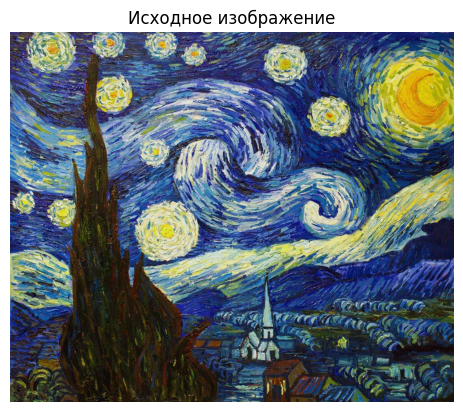

In [3]:
# Считываем изображение
img = cv.imread('/kaggle/input/images/starry_night.jpg')
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Исходное изображение')
plt.show()

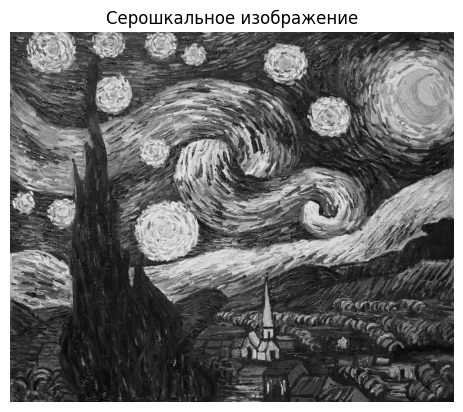

In [5]:
# Преобразуем в серошкальный формат
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')
plt.title('Серошкальное изображение')
plt.axis('off')
plt.show()

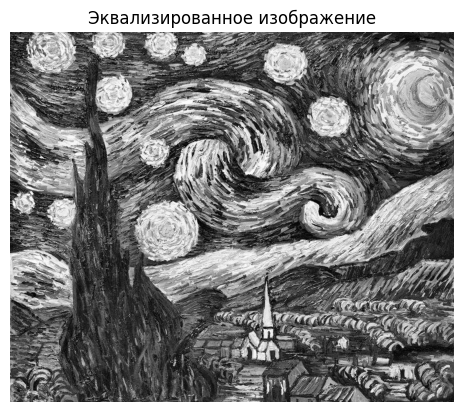

In [8]:
# Проводим адаптивную эквализацию гистограммы
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
equalized = clahe.apply(gray)
plt.imshow(equalized, cmap='gray')
plt.axis('off')
plt.title('Эквализированное изображение')
plt.show()

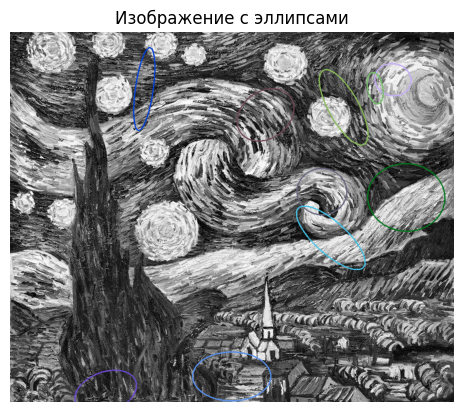

In [9]:
# Добавляем эллипсы произвольного цвета
equalized_color = cv.cvtColor(equalized, cv.COLOR_GRAY2BGR)
for _ in range(10):
    center = (random.randint(0, equalized_color.shape[1] - 1), random.randint(0, equalized_color.shape[0] - 1))
    axes = (random.randint(10, 100), random.randint(10, 100))
    angle = random.randint(0, 360)
    color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
    cv.ellipse(equalized_color, center, axes, angle, 0, 360, color, thickness=2)

plt.imshow(cv.cvtColor(equalized_color, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Изображение с эллипсами')
plt.show()

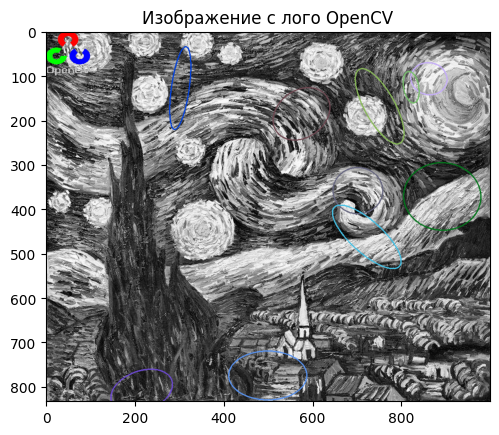

In [10]:
# Добавляем лого OpenCV
img2 = cv.imread('/kaggle/input/images/opencv.png')

# Масштабируем лого до небольшого размера, например, 100x100
img2 = cv.resize(img2, (100, 100))

rows, cols, _ = img2.shape
if rows > equalized_color.shape[0] or cols > equalized_color.shape[1]:
    raise ValueError("Лого слишком большое для изображения")

# Создаем маску для лого
img2gray = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)
ret, mask = cv.threshold(img2gray, 10, 255, cv.THRESH_BINARY)
mask_inv = cv.bitwise_not(mask)

# ROI в эквализированном изображении (верхний левый угол)
roi = equalized_color[0:rows, 0:cols]

# Затемняем область лого в ROI
img1_bg = cv.bitwise_and(roi, roi, mask=mask_inv)

# Берем только регион лого из изображения лого
img2_fg = cv.bitwise_and(img2, img2, mask=mask)

# Вставляем лого в ROI и модифицируем основное изображение
dst = cv.add(img1_bg, img2_fg)
equalized_color[0:rows, 0:cols] = dst

plt.imshow(cv.cvtColor(equalized_color, cv.COLOR_BGR2RGB))
plt.title('Изображение с лого OpenCV')
plt.show()

In [11]:
# Сохраняем результат в формате PNG
cv.imwrite('result.png', equalized_color)

True